# Footpath sanity checks

Validates OSM-based walking distances in `footpaths_osm`.

**Two stop sources:**
- `stops` — region-filtered (Lausanne area), used for the crow-fly validation
- `all_stops` — all Switzerland from shared schema, used for any-city search

In [ ]:
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)  # ensures relative paths (data/, artifacts/) resolve correctly

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config.settings import get_settings
from src.config.trino_connection import create_trino_connection

settings = get_settings()
conn     = create_trino_connection(settings)
print('Connected to Trino')
print(f'Footpaths table : {settings.user_schema}.footpaths_osm')
print(f'Shared schema   : {settings.shared_schema}')

In [19]:
# footpaths_osm = all Switzerland (built once by create_footpath_data.py)
fp = pd.read_sql(f'SELECT * FROM {settings.user_schema}.footpaths_osm', conn)

# stops (user schema) = region-filtered, only for validation against crow-fly
stops = pd.read_sql(
    f'SELECT stop_id, stop_name, stop_lat, stop_lon FROM {settings.user_schema}.stops', conn
)

# all_stops = entire Switzerland, for searching any city
max_pub_date = pd.read_sql(
    f"SELECT MAX(pub_date) AS d FROM {settings.shared_schema}.sbb_stop_times", conn
).iloc[0]['d']
all_stops = pd.read_sql(f"""
    SELECT stop_id, stop_lat, stop_lon FROM (
        SELECT
            TRY_CAST(split_part(stop_id, ':', 1) AS INTEGER) AS stop_id,
            MAX(stop_name) AS stop_name,
            AVG(stop_lat)  AS stop_lat,
            AVG(stop_lon)  AS stop_lon
        FROM {settings.shared_schema}.sbb_stops
        WHERE pub_date = DATE '{max_pub_date}'
          AND split_part(stop_id, ':', 1) LIKE '85%'
        GROUP BY TRY_CAST(split_part(stop_id, ':', 1) AS INTEGER)
    ) WHERE stop_id IS NOT NULL
""", conn)

# re-add stop_name from the subquery (Trino drops aliases in subqueries in some versions)
if 'stop_name' not in all_stops.columns:
    all_stops = pd.read_sql(f"""
        SELECT
            TRY_CAST(split_part(stop_id, ':', 1) AS INTEGER) AS stop_id,
            MAX(stop_name) AS stop_name,
            AVG(stop_lat)  AS stop_lat,
            AVG(stop_lon)  AS stop_lon
        FROM {settings.shared_schema}.sbb_stops
        WHERE pub_date = DATE '{max_pub_date}'
          AND split_part(stop_id, ':', 1) LIKE '85%'
        GROUP BY TRY_CAST(split_part(stop_id, ':', 1) AS INTEGER)
        HAVING TRY_CAST(split_part(stop_id, ':', 1) AS INTEGER) IS NOT NULL
    """, conn)

print(f'footpaths_osm : {len(fp):,} directed edges (all Switzerland)')
print(f'stops         : {len(stops):,} stops (region only)')
print(f'all_stops     : {len(all_stops):,} stops (all Switzerland)')
fp.head()

/tmp/ipykernel_2065701/348383162.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fp = pd.read_sql(f'SELECT * FROM {settings.user_schema}.footpaths_osm', conn)
/tmp/ipykernel_2065701/348383162.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  stops = pd.read_sql(
/tmp/ipykernel_2065701/348383162.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  max_pub_date = pd.read_sql(
/tmp/ipykernel_2065701/348383162.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sql

footpaths_osm : 52,104 directed edges (all Switzerland)
stops         : 390 stops (region only)
all_stops     : 25,752 stops (all Switzerland)


,a_stop_id,b_stop_id,distance,walk_time_min
0,8581224,8579764,339.9783,8.799567
1,8580746,8530789,475.6586,11.513172
2,8589551,8589641,438.9115,10.778231
3,8589152,8589141,246.7203,6.934407
4,8510082,8510083,423.6774,10.473548


Total edges: 52,104  |  Non-zero: 52,016  |  Zero-distance (same platform): 88

       distance  walk_time_min
count  52016.00       52016.00
mean     336.33           8.73
std      112.82           2.26
min        2.97           2.06
25%      262.04           7.24
50%      352.29           9.05
75%      429.79          10.60
max      499.98          12.00


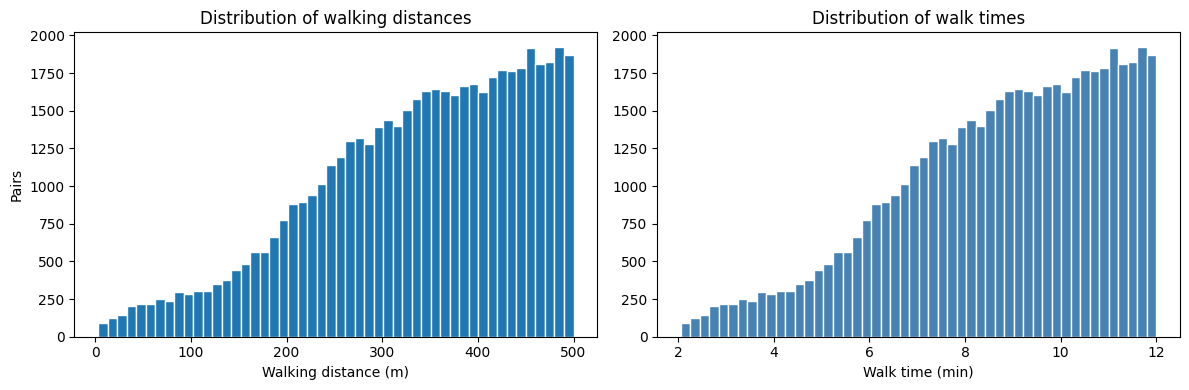

In [20]:
# Basic stats — filter out 0m pairs (collocated platforms of the same station)
fp_nonzero = fp[fp['distance'] > 1.0]
print(f'Total edges: {len(fp):,}  |  Non-zero: {len(fp_nonzero):,}  |  Zero-distance (same platform): {len(fp) - len(fp_nonzero)}')
print()
print(fp_nonzero[['distance', 'walk_time_min']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(fp_nonzero['distance'], bins=50, edgecolor='white')
axes[0].set_xlabel('Walking distance (m)')
axes[0].set_ylabel('Pairs')
axes[0].set_title('Distribution of walking distances')
axes[1].hist(fp_nonzero['walk_time_min'], bins=50, edgecolor='white', color='steelblue')
axes[1].set_xlabel('Walk time (min)')
axes[1].set_title('Distribution of walk times')
plt.tight_layout()
plt.show()

Pairs checked (region stops only): 1,492
Violations OSM < crow-fly - 5m  : 10 (0.67%)
Max shortfall: 9.5 m

Walk/crow-fly ratio stats (Lausanne region):
count    1492.000
mean        1.307
std         0.462
min         0.920
25%         1.082
50%         1.211
75%         1.374
max         7.526
Name: ratio, dtype: float64


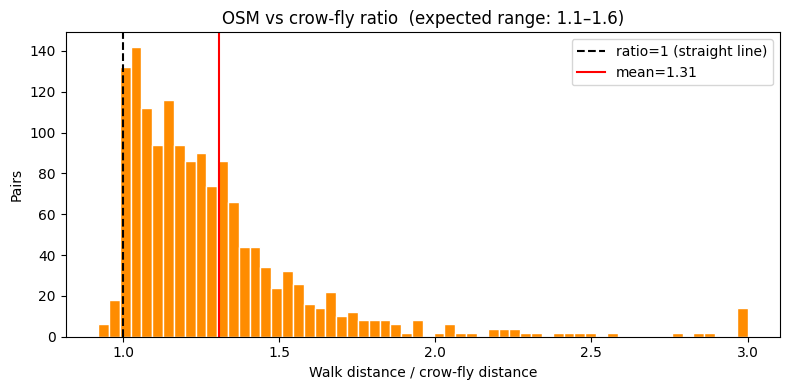

In [21]:
# Sanity check: OSM walk distance should be >= crow-fly distance.
# A small number of violations is expected: the KD-tree snaps stops to the nearest
# OSM node, which may not sit exactly at the stop coordinates. The graph path between
# two snapped nodes can be marginally shorter than the straight line between the
# original stop lat/lons. Violations should be small (<1%) and tiny in magnitude.
merged = (
    fp_nonzero
    .merge(stops[['stop_id', 'stop_lat', 'stop_lon']], left_on='a_stop_id', right_on='stop_id')
    .rename(columns={'stop_lat': 'lat_a', 'stop_lon': 'lon_a'}).drop(columns='stop_id')
    .merge(stops[['stop_id', 'stop_lat', 'stop_lon']], left_on='b_stop_id', right_on='stop_id')
    .rename(columns={'stop_lat': 'lat_b', 'stop_lon': 'lon_b'}).drop(columns='stop_id')
)

R = 6_371_000.0
phi1, phi2 = np.radians(merged.lat_a), np.radians(merged.lat_b)
a = (
    np.sin(np.radians(merged.lat_b - merged.lat_a) / 2) ** 2
    + np.cos(phi1) * np.cos(phi2) * np.sin(np.radians(merged.lon_b - merged.lon_a) / 2) ** 2
)
merged['crow_fly_m'] = 2 * R * np.arcsin(np.sqrt(a))
merged['ratio']      = merged['distance'] / merged['crow_fly_m'].clip(lower=1.0)

violations = merged[merged['distance'] < merged['crow_fly_m'] - 5.0]  # 5m tolerance
print(f'Pairs checked (region stops only): {len(merged):,}')
print(f'Violations OSM < crow-fly - 5m  : {len(violations)} ({100*len(violations)/len(merged):.2f}%)')
if len(violations):
    print(f'Max shortfall: {(violations["crow_fly_m"] - violations["distance"]).max():.1f} m')
print(f'\nWalk/crow-fly ratio stats (Lausanne region):')
print(merged['ratio'].describe().round(3))

plt.figure(figsize=(8, 4))
plt.hist(merged['ratio'].clip(upper=3.0), bins=60, edgecolor='white', color='darkorange')
plt.axvline(1.0, color='black', linestyle='--', label='ratio=1 (straight line)')
plt.axvline(merged['ratio'].mean(), color='red', linestyle='-', label=f'mean={merged["ratio"].mean():.2f}')
plt.xlabel('Walk distance / crow-fly distance')
plt.ylabel('Pairs')
plt.title('OSM vs crow-fly ratio  (expected range: 1.1–1.6)')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Spot-check: search any Swiss city — uses all_stops (all Switzerland)
stop_name_query = 'Zürich'   # try: Genève, Zürich, Bern, Luzern, Basel

candidates = all_stops[all_stops['stop_name'].str.contains(stop_name_query, case=False, na=False)]
print(f'Stops matching "{stop_name_query}" ({len(candidates)} found):')
print(candidates[['stop_id', 'stop_name']].head(10).to_string(index=False))

Stops matching "Zürich" (476 found):
 stop_id                 stop_name
 8576262  Zürich, Zehntenhausplatz
 8587349    Zürich, Bahnhofquai/HB
 8591121      Zürich, Eschergutweg
 8503000                 Zürich HB
 8503446 Zürich Landesmuseum (See)
 8591112         Zürich, Dorflinde
 8591276         Zürich, Milchbuck
 8591298    Zürich, Ottikerstrasse
 8591086       Zürich, Birchdörfli
 8591115   Zürich, Drusbergstrasse


In [24]:
# Inspect walking neighbours of a chosen stop.
#
# Two ways to pick a stop:
#   Option A: use position  →  candidates.iloc[0]['stop_id']   (first search result)
#   Option B: use stop_id directly →  chosen_stop_id = 8592010
#
# iloc[N] is a ROW POSITION (0 = first row), NOT a stop_id!

chosen_stop_id = candidates.iloc[0]['stop_id']   # first result from the search above
chosen_name    = candidates.iloc[0]['stop_name']

# stop_name lookup comes from all_stops so we can display any Swiss stop
neighbours = (
    fp[fp['a_stop_id'] == chosen_stop_id]
    .merge(all_stops[['stop_id', 'stop_name']], left_on='b_stop_id', right_on='stop_id')
    .drop(columns='stop_id')
    .sort_values('distance')
    .rename(columns={'stop_name': 'neighbour'})
    [['neighbour', 'b_stop_id', 'distance', 'walk_time_min']]
)

print(f'Walking neighbours of "{chosen_name}" (stop_id={chosen_stop_id}):')
if neighbours.empty:
    print('  No walking neighbours found in footpaths_osm (stop may be in an area without nearby stops).')
else:
    print(neighbours.to_string(index=False))

Walking neighbours of "Zürich, Zehntenhausplatz" (stop_id=8576262):
                neighbour  b_stop_id  distance  walk_time_min
Zürich Affoltern, Bahnhof    8591054  230.1913       6.603827
         Zürich Affoltern    8503008  348.6814       8.973628
      Zürich, Schauenberg    8591338  392.5120       9.850240
Zürich, Hungerbergstrasse    8576263  464.5160      11.290320
         Zürich, Fronwald    8591153  476.5732      11.531464


In [25]:
# Stops with the most walking connections (hubs) — uses all_stops for full Switzerland
hub_counts = (
    fp.groupby('a_stop_id').size().reset_index(name='n_neighbours')
    .merge(all_stops[['stop_id', 'stop_name']], left_on='a_stop_id', right_on='stop_id', how='left')
    .sort_values('n_neighbours', ascending=False)
    .head(20)
    [['stop_name', 'a_stop_id', 'n_neighbours']]
)
print('Top 20 stops by number of walking neighbours (all Switzerland):')
print(hub_counts.to_string(index=False))

Top 20 stops by number of walking neighbours (all Switzerland):
                     stop_name  a_stop_id  n_neighbours
    Neuchâtel, Terreaux Muséum    8579624            16
    Muralto, Residenza Montana    8591561            15
           Genève, Saint-Léger    8511618            14
 Genève, Musée art et histoire    8592851            14
               Saas-Fee, Royal    8594880            13
             Neuchâtel, écluse    8571848            13
La Chaux-de-Fonds, Gr Fontaine    8571884            13
      Montreux, rue de la Gare    8593938            13
          Chur, Alexanderplatz    8595591            13
         Paradiso, Via Cattori    8591635            13
          Wohlen AG, Postplatz    8580303            13
           Lausanne, Chauderon    8592010            13
           Frauenfeld, Rathaus    8594753            13
          Lausanne, Port-Franc    8592098            13
               Genève, Athénée    8592779            13
        Genève, Hôtel-de-Ville    859283